### Imports

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm import tqdm

### Load kedro

In [2]:
import os

os.chdir("../../")

%load_ext kedro.ipython

[04/27/26 18:48:42] INFO     Using                                                                  ]8;id=577196;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=48587;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pac                
                             kages\kedro\framework\project\rich_logging.yml' as logging                            
                             configuration.                                                                        

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=570479;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=374066;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=840923;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=652792;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=899453;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=30539;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\cxr-training-pipeli                
                             ne.                                                                                   
                             To set a different path, run '%reload_kedro <project_root>'                           

[04/27/26 18:48:45] WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=883794;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=932361;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\requests\__init__.py:113: RequestsDependencyWarning: urllib3                     
                             (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't                   
                             match a supported version!                                                            
                               warnings.warn(                                                                      
                                                                                                                   

...

                    WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=227819;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=759137;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning:                   
                             The filesystem tracking backend (e.g., './mlruns') is deprecated as of                
                             February 2026. Consider transitioning to a database backend (e.g.,                    
                             'sqlite:///mlflow.db') to take advantage of the latest MLflow                         
                             features. See                                                                         
                             https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store                   
                             for migration guidance.                                                               
                               return FileStore(store_uri, store_uri)                                              
                                                                                                                   

[04/27/26 18:49:08] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=976256;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=238192;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[04/27/26 18:49:09] INFO     Kedro project cxr-training-pipeline                                    ]8;id=734509;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=785129;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=32957;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=281464;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=131983;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=423268;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#154\154]8;;\

### Files

In [3]:
xray_train_val = catalog.load("xray_train_val")
xray_test = catalog.load("xray_test")
segmentation_masks = catalog.load("cxr8_segmentation_masks")

[04/27/26 18:55:42] INFO     Loading data from xray_train_val (CSVDataset)...                  ]8;id=914285;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=46918;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

                    INFO     Loading data from xray_test (CSVDataset)...                       ]8;id=458277;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=551582;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

                    INFO     Loading data from cxr8_segmentation_masks (CSVDataset)...         ]8;id=41153;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=846755;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [6]:
segmentation_masks.head()

,Image Index,Dice RCA (Mean),Dice RCA (Max),Landmarks,Left Lung,Right Lung,Heart,Height,Width
0,00025787_047.png,0.826465,0.870102,"488,115,449,118,411,132,374,153,344,177,324,20...",200402 3 201422 11 202442 18 203463 24 204483 ...,118243 8 119254 24 120265 40 121281 51 122302 ...,448036 9 449048 27 450064 41 451086 48 452107 ...,1024,1024
1,00026251_000.png,0.833988,0.928886,"426,124,386,128,345,146,303,171,270,203,246,23...",136822 22 137826 46 138848 52 139870 58 140892...,127399 7 128413 21 129427 35 130441 49 131458 ...,445964 26 446985 33 448007 40 449028 47 450049...,1024,1024
2,00026194_002.png,0.759308,0.794598,"439,217,402,226,371,245,345,271,324,297,311,32...",189085 9 190096 27 191113 39 192135 45 193158 ...,221645 20 222646 45 223666 50 224686 56 225706...,395796 5 396816 13 397836 21 398856 29 399877 ...,1024,1024
3,00025227_012.png,0.903819,0.930990,"397,79,357,82,314,98,274,128,236,165,212,205,1...",100976 22 101998 45 103020 49 104042 53 105064...,81288 8 82299 23 83309 40 84325 50 85346 55 86...,498141 13 499161 29 500181 36 501201 43 502221...,1024,1024
4,00028166_003.png,0.850303,0.869093,"392,180,374,184,353,201,327,225,304,250,284,27...",163435 4 164455 12 165475 20 166496 27 167516 ...,184711 4 185731 12 186750 20 187770 27 188791 ...,464455 11 465455 37 466458 59 467469 74 468485...,1024,1024


### Cropping image to bbox

In [ ]:
def rle_to_mask(rle_str: str, height: int, width: int) -> np.ndarray:
    if not isinstance(rle_str, str) or not rle_str.strip():
        return np.zeros((height, width), dtype=np.uint8)

    tokens = [int(x) for x in rle_str.split()]
    starts = np.array(tokens[0::2]) - 1  # RLE is 1-based
    lengths = np.array(tokens[1::2])
    ends = starts + lengths

    flat = np.zeros(height * width, dtype=np.uint8)
    for start, end in zip(starts, ends):
        flat[start:end] = 1

    return flat.reshape((height, width))


def get_combined_mask_by_image_index(
    image_index: str,
    segmentation_masks_df: pd.DataFrame,
    height: int,
    width: int,
    mask_columns: list[str] = ["Left Lung", "Right Lung", "Heart"],
) -> np.ndarray:
    rows = segmentation_masks_df.loc[
        segmentation_masks_df["Image Index"] == image_index
    ]

    if rows.empty:
        return np.zeros((height, width), dtype=np.uint8)

    row = rows.iloc[0]
    organ_masks = [rle_to_mask(row.get(col, ""), height, width) for col in mask_columns]
    return np.maximum.reduce(organ_masks)


def get_bbox_coordinates(mask: np.ndarray) -> tuple[int, int, int, int] | None:
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)

    if not rows.any() or not cols.any():
        return None

    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]

    # Return exclusive max bounds for direct slicing: img[y_min:y_max, x_min:x_max]
    return int(x_min), int(y_min), int(x_max) + 1, int(y_max) + 1


def expand_bbox(
    bbox: tuple[int, int, int, int],
    img_shape: tuple[int, int],
    margin_ratio: float = 0.08,
    min_bbox_size: int = 64,
) -> tuple[int, int, int, int]:
    x_min, y_min, x_max, y_max = bbox
    height, width = img_shape

    bbox_w = x_max - x_min
    bbox_h = y_max - y_min
    margin_x = int(round(bbox_w * margin_ratio))
    margin_y = int(round(bbox_h * margin_ratio))

    x_min = max(0, x_min - margin_x)
    y_min = max(0, y_min - margin_y)
    x_max = min(width, x_max + margin_x)
    y_max = min(height, y_max + margin_y)

    if (x_max - x_min) < min_bbox_size:
        to_add = min_bbox_size - (x_max - x_min)
        left = to_add // 2
        right = to_add - left
        x_min = max(0, x_min - left)
        x_max = min(width, x_max + right)

    if (y_max - y_min) < min_bbox_size:
        to_add = min_bbox_size - (y_max - y_min)
        top = to_add // 2
        bottom = to_add - top
        y_min = max(0, y_min - top)
        y_max = min(height, y_max + bottom)

    return x_min, y_min, x_max, y_max


def crop_to_bbox(img: np.ndarray, bbox_coords: tuple[int, int, int, int]) -> np.ndarray:
    x_min, y_min, x_max, y_max = bbox_coords
    return img[y_min:y_max, x_min:x_max]


def crop_resize_with_mask(
    img_np: np.ndarray,
    image_index: str,
    segmentation_masks_df: pd.DataFrame,
    output_size: int,
    margin_ratio: float = 0.08,
    min_bbox_size: int = 64,
) -> np.ndarray:
    combined_mask = get_combined_mask_by_image_index(
        image_index=image_index,
        segmentation_masks_df=segmentation_masks_df,
        height=img_np.shape[0],
        width=img_np.shape[1],
    )
    bbox = get_bbox_coordinates(combined_mask)

    if bbox is not None:
        bbox = expand_bbox(
            bbox=bbox,
            img_shape=img_np.shape,
            margin_ratio=margin_ratio,
            min_bbox_size=min_bbox_size,
        )
        img_np = crop_to_bbox(img_np, bbox)

    resized = Image.fromarray(img_np).resize((output_size, output_size), Image.BILINEAR)
    return np.array(resized, dtype=np.uint8)


def precompute_mask_cropped_images_to_npy(
    df: pd.DataFrame,
    segmentation_masks_df: pd.DataFrame,
    images_dir: str,
    output_path: str,
    image_col: str = "image_index",
    output_size: int = 512,
    margin_ratio: float = 0.08,
    min_bbox_size: int = 64,
) -> None:
    images_dir = Path(images_dir)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    n = len(df)
    arr = np.lib.format.open_memmap(
        output_path,
        dtype=np.uint8,
        mode="w+",
        shape=(n, output_size, output_size),
    )

    for i, image_name in enumerate(tqdm(df[image_col].tolist(), total=n)):
        img_path = images_dir / image_name

        with Image.open(img_path) as img:
            img_np = np.array(img.convert("L"), dtype=np.uint8)

        img_np = crop_resize_with_mask(
            img_np=img_np,
            image_index=image_name,
            segmentation_masks_df=segmentation_masks_df,
            output_size=output_size,
            margin_ratio=margin_ratio,
            min_bbox_size=min_bbox_size,
        )

        arr[i] = img_np

    arr.flush()
    print(f"Saved memmap to: {output_path}")

In [8]:
def get_image(idx: int) -> np.ndarray:
    image_index = segmentation_masks.loc[idx, "Image Index"]
    img_path = os.path.join("data", "01_raw", "images", image_index)
    return np.array(plt.imread(img_path))

Bounding Box Coordinates: (np.int64(156), np.int64(23), np.int64(812), np.int64(674))


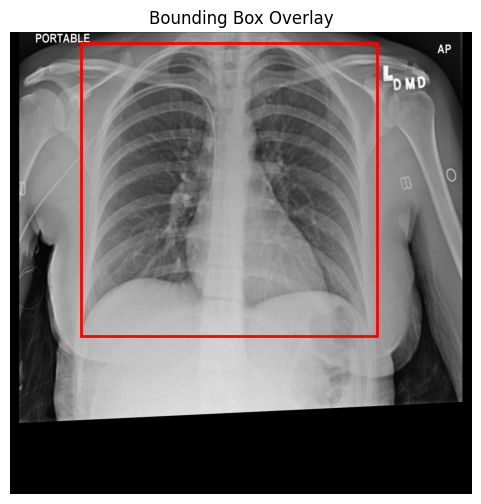

In [ ]:
idx = 1251
image = get_image(idx)
image_index = segmentation_masks.loc[idx, "Image Index"]

combined_mask = get_combined_mask_by_image_index(
    image_index=image_index,
    segmentation_masks_df=segmentation_masks,
    height=1024,
    width=1024,
 )
bbox_coords = get_bbox_coordinates(combined_mask)
print(f"Image: {image_index}")
print(f"Bounding Box Coordinates: {bbox_coords}")

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.imshow(combined_mask, cmap="pink_r", alpha=0.35)
if bbox_coords is not None:
    x_min, y_min, x_max, y_max = bbox_coords
    rect = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    plt.gca().add_patch(rect)
plt.title("Mask + Bounding Box Overlay")
plt.axis("off")
plt.show()

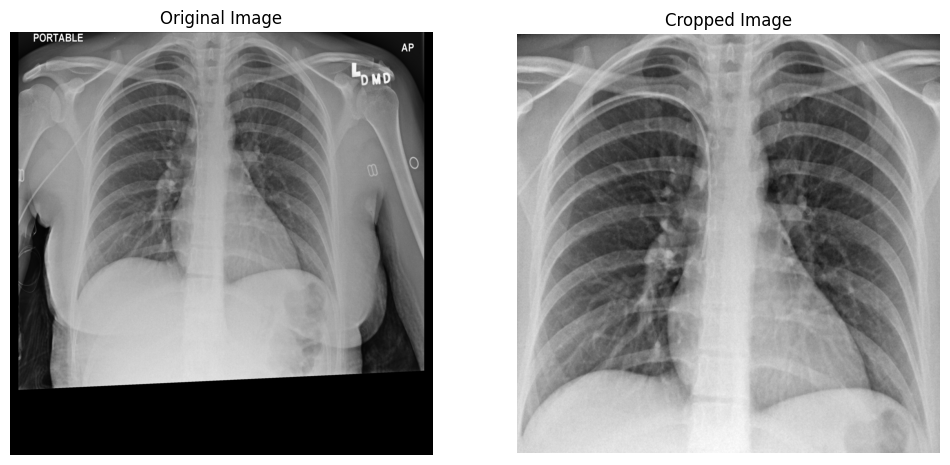

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")
cropped_image = crop_to_bbox(image, bbox_coords)
axes[1].imshow(cropped_image, cmap="gray")
axes[1].set_title("Cropped Image")
axes[1].axis("off")
plt.show()

### Precompute cropped train/test arrays

In [ ]:
OUT_DIR = Path("data/02_intermediate/precomputed_images_masked")
OUT_DIR.mkdir(parents=True, exist_ok=True)

precompute_mask_cropped_images_to_npy(
    df=xray_train_val,
    segmentation_masks_df=segmentation_masks,
    images_dir="data/01_raw/images",
    output_path=OUT_DIR / "train_images.npy",
    image_col="image_index",
    output_size=512,
    margin_ratio=0.08,
    min_bbox_size=64,
 )

precompute_mask_cropped_images_to_npy(
    df=xray_test,
    segmentation_masks_df=segmentation_masks,
    images_dir="data/01_raw/images",
    output_path=OUT_DIR / "test_images.npy",
    image_col="image_index",
    output_size=512,
    margin_ratio=0.08,
    min_bbox_size=64,
 )

### Load precomputed arrays and build dataset

In [ ]:
from cxr_training_pipeline.datasets.cxr_dataset import ImageOnlyDataset

PATHOLOGY_LIST = [
    "Infiltration",
    "Effusion",
    "Atelectasis",
    "Nodule",
    "Mass",
    "Pneumothorax",
    "Consolidation",
    "Pleural_Thickening",
    "Cardiomegaly",
    "Emphysema",
    "Edema",
    "Fibrosis",
    "Pneumonia",
    "Hernia",
]

train_images_masked = np.load(OUT_DIR / "train_images.npy", mmap_mode="r")
test_images_masked = np.load(OUT_DIR / "test_images.npy", mmap_mode="r")

train_labels = xray_train_val[PATHOLOGY_LIST].values.astype(np.float32)
test_labels = xray_test[PATHOLOGY_LIST].values.astype(np.float32)

train_dataset = ImageOnlyDataset(
    df=xray_train_val,
    images_array=train_images_masked,
    labels_array=train_labels,
    indices=None,
    transform=None,
 )

sample = train_dataset[0]
print(sample["image"].shape, sample["image"].dtype)
print(sample["target"].shape, sample["target"].dtype)
print(sample["image_index"])